# NLP: Análisis de viralidad y Narrativas de los Juegos Olímpicos de París 2024

## Caso de estudio: Yusuf Dikec

## Objetivo del proyecto: 

Elegir un tema relacionado con los Juegos Olímpicos, buscar contenido en artículos, redes sociales, noticias u otras fuentes, y aplicar técnicas de NLP para realizar un tratamiento y análisis de los datos.

Para realizar este estudio, nos enfocamos en uno de los casos más virbales de los Juegos Olímpicos de París 2024, el tirador turco **Yusuf Dikec**, quién capturó la atención global, no sólo por su medalla de plata, sino por su actitud despreocupada y falta de equipamiento especializado.

## Metodología:
1. **Recolección de datos**: Hacemos uso de la API de Youtube para recolectar comentarios relacionados con Yusuf Dikec y su participación en los Juegos Olímpicos de París 2024, en este caso sólo nos vamos a central en los comentarios de un único vídeo con numeros comentarios.
2. **Preprocesamiento de datos**: Normalizamos los comentarios y filtramos el ruido para analizar sólo el contenido relevante.
3. **Técnicas de NLP**:
    - Análisis de sentimiento VADER para evaluar los sentimientos expresados en los comentarios (positivo, negativo, neutral) de la gente hacia Yusuf Dikec.
    - Extracción de palabras clave **N-Grams** para identificar términos y frases recurrentes en los comentarios.
    - Modelado de temas **LDA** (Latent Dirichlet Allocation), es una técnica de modelado no supervisado que permite descubrir automáticamente las temáticas presentes en el conjunto de datos (clusters de palabras que representan temas).
4. **Visualización de datos**: Representación de la evolución temporal de los sentimientos, n-grams más frecuentes y temas identificados mediante gráficos y tablas.

In [63]:
import os
import re
import time
import warnings

import pandas as pd
from googleapiclient.discovery import build
from googleapiclient.errors import HttpError


import nltk
from nltk.sentiment import SentimentIntensityAnalyzer

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

In [2]:
API_KEY = os.getenv("YOUTUBE_API_KEY")

In [3]:
videos_dats_dict = {
    "The Coolest Olympic Athlete? ‘Gearless’ Turkish shooter Yusuf Dikec goes viral 🇹🇷😎 | #Paris2024": "EHnNJKSE87Y",  # Sentimiento: Humor - Viral positivo
}

In [4]:
def fetch_youtube_comments(videos_dict):
    try:
        youtube = build('youtube', 'v3', developerKey=API_KEY)
    except Exception as e:
        print(f"Error initializing YouTube API client: {e}")
        return pd.DataFrame()
    data_list = []

    for etiqueta, video_id in videos_dict.items():
        print(f"Fetching comments for video: {etiqueta}, ID: {video_id}")
        count_video = 0
        next_page_token = None

        while True:
            try:
                request = youtube.commentThreads().list(
                    part="snippet",
                    videoId=video_id,
                    maxResults=100,
                    pageToken=next_page_token,
                    textFormat="plainText"
                )
                response = request.execute()
                for item in response.get("items", []):
                    snippet = item["snippet"]["topLevelComment"]["snippet"]
                    data_list.append({
                        "video_id": video_id,
                        "video_label": etiqueta,
                        "text": snippet.get("textDisplay"),
                        "published_at": snippet.get("publishedAt"),
                        "like_count": snippet.get("likeCount"),
                    })
                    count_video += 1
                if count_video %500 == 0:
                    print(f"Fetched {count_video} comments for video ID: {video_id}")
                next_page_token = response.get("nextPageToken")
                if not next_page_token:
                    break # No more pages / comments
                time.sleep(0.5)  # To respect rate limits
            except HttpError as e:
                if e.resp.status == 403:
                    print("Limit reached or access forbidden. Waiting before retrying...")
                    return pd.DataFrame(data_list)
                elif e.resp.status == 404:
                    print(f"Video not found: {video_id}, or comments disabled.")
                    break
                else:
                    print(f"HTTP error {e.resp.status} occurred: {e.content}")
                    break
            print(f"Total comments fetched for video ID {video_id}: {count_video}")
    return pd.DataFrame(data_list)

In [5]:
df_raw_comments = fetch_youtube_comments(videos_dats_dict)
print(f"Total comments fetched across all videos: {len(df_raw_comments)}")
df_raw_comments.to_csv("yusuf_dikec_viral_comments.csv", index=False)

Fetching comments for video: The Coolest Olympic Athlete? ‘Gearless’ Turkish shooter Yusuf Dikec goes viral 🇹🇷😎 | #Paris2024, ID: EHnNJKSE87Y
Total comments fetched for video ID EHnNJKSE87Y: 100
Total comments fetched for video ID EHnNJKSE87Y: 200
Total comments fetched for video ID EHnNJKSE87Y: 300
Total comments fetched for video ID EHnNJKSE87Y: 400
Fetched 500 comments for video ID: EHnNJKSE87Y
Total comments fetched for video ID EHnNJKSE87Y: 500
Total comments fetched for video ID EHnNJKSE87Y: 600
Total comments fetched for video ID EHnNJKSE87Y: 700
Total comments fetched for video ID EHnNJKSE87Y: 800
Total comments fetched for video ID EHnNJKSE87Y: 900
Fetched 1000 comments for video ID: EHnNJKSE87Y
Total comments fetched for video ID EHnNJKSE87Y: 1000
Total comments fetched for video ID EHnNJKSE87Y: 1100
Total comments fetched for video ID EHnNJKSE87Y: 1200
Total comments fetched for video ID EHnNJKSE87Y: 1300
Total comments fetched for video ID EHnNJKSE87Y: 1400
Fetched 1500 com

In [6]:
df = pd.read_csv("yusuf_dikec_viral_comments.csv")
df.head()

,video_id,video_label,text,published_at,like_count
0,EHnNJKSE87Y,The Coolest Olympic Athlete? ‘Gearless’ Turkis...,🇹🇷🇹🇷🇹🇷🇹🇷🇹🇷🇹🇷🇹🇷🇹🇷🇹🇷🇹🇷🇹🇷🇹🇷🇹🇷🇹🇷🇹🇷🇹🇷🇹🇷🇹🇷🇹🇷🇹🇷,2025-12-28T15:57:55Z,0
1,EHnNJKSE87Y,The Coolest Olympic Athlete? ‘Gearless’ Turkis...,Difference between amateurs and professionals ...,2025-12-28T11:07:06Z,0
2,EHnNJKSE87Y,The Coolest Olympic Athlete? ‘Gearless’ Turkis...,I will send someone capable..,2025-12-28T10:23:18Z,0
3,EHnNJKSE87Y,The Coolest Olympic Athlete? ‘Gearless’ Turkis...,"Ice cold, this guy must be an assassin in his ...",2025-12-28T03:28:32Z,0
4,EHnNJKSE87Y,The Coolest Olympic Athlete? ‘Gearless’ Turkis...,Just dumb. Objevtively you are better with the...,2025-12-27T14:52:48Z,0


## Preprocesamiento de datos

Defininimos el rango del filtro de fechas para analizar la viralidad durante el evento olímpico y un mes más para observar la evolución posterior.

In [30]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\.\S+', '', text)
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\d+', '', text)
    # text = re.sub(r'\s+', ' ', text).strip()
    return text

def preprocess_comments(df):
    df['published_at'] = pd.to_datetime(df['published_at'])
    fecha_ini = df['published_at'].min() - pd.Timedelta(days=1)
    fecha_fin = df['published_at'].max() + pd.DateOffset(months=1)
    df_filtered = df[(df['published_at'] >= fecha_ini) & (df['published_at'] <= fecha_fin)].copy()

    df_filtered['clean_text'] = df_filtered['text'].apply(clean_text)
    df_filtered = df_filtered[df_filtered['clean_text'].str.len() > 3].reset_index(drop=True)
    return df_filtered

In [43]:
df_processed = preprocess_comments(df)
print(f"Comentarios totales {len(df)} y analizamos {len(df_processed)} comentarios después del preprocesamiento.")

Comentarios totales 4446 y analizamos 4079 comentarios después del preprocesamiento.


# Técnicas de NLP

1. Análisis de sentimiento VADER
   1. Se utiliza la librería NLTK para aplicar el análisis de sentimiento VADER a los comentarios preprocesados.
   2. Se calcula el puntaje de sentimiento para cada comentario y se clasifica como positivo, negativo o neutral.
2. Extracción de palabras clave N-Grams
   1. Se generan n-grams (bi-grams y tri-grams) a partir de los comentarios preprocesados.
   2. Se cuentan las frecuencias de los n-grams para identificar los términos y frases más comunes.
3. Modelado de temas LDA
   1. Se utiliza la librería Gensim para aplicar el modelo LDA a los comentarios preprocesados.
   2. Se identifican los temas predominantes en los comentarios

In [44]:
def analisis_sentimiento(df):
    sia = SentimentIntensityAnalyzer()
    df['sentiment_scores'] = df['clean_text'].apply(lambda x: sia.polarity_scores(x)['compound'])
    df['sentiment'] = df['sentiment_scores'].apply(lambda score: 'positive' if score > 0.05 else ('negative' if score < -0.05 else 'neutral'))
    return df


In [45]:
df_processed = analisis_sentimiento(df_processed)
df_processed.head()

,video_id,video_label,text,published_at,like_count,clean_text,sentiment_scores,sentiment
0,EHnNJKSE87Y,The Coolest Olympic Athlete? ‘Gearless’ Turkis...,Difference between amateurs and professionals ...,2025-12-28 11:07:06+00:00,0,difference between amateurs and professionals ...,0.5719,positive
1,EHnNJKSE87Y,The Coolest Olympic Athlete? ‘Gearless’ Turkis...,I will send someone capable..,2025-12-28 10:23:18+00:00,0,i will send someone capable,0.3818,positive
2,EHnNJKSE87Y,The Coolest Olympic Athlete? ‘Gearless’ Turkis...,"Ice cold, this guy must be an assassin in his ...",2025-12-28 03:28:32+00:00,0,ice cold this guy must be an assassin in his d...,0.0000,neutral
3,EHnNJKSE87Y,The Coolest Olympic Athlete? ‘Gearless’ Turkis...,Just dumb. Objevtively you are better with the...,2025-12-27 14:52:48+00:00,0,just dumb objevtively you are better with the ...,-0.0717,negative
4,EHnNJKSE87Y,The Coolest Olympic Athlete? ‘Gearless’ Turkis...,he's shooting both eyes open.. that's because ...,2025-12-27 08:38:42+00:00,0,hes shooting both eyes open thats because of h...,0.0000,neutral


In [46]:
def bias_sentimiento(df):
    vec_bigrama = CountVectorizer(ngram_range=(2, 2), stop_words='english', max_features=10)
    bow_bigrama = vec_bigrama.fit_transform(df['clean_text'])
    sum_words = bow_bigrama.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec_bigrama.vocabulary_.items()]
    df_bigramas = pd.DataFrame(sorted(words_freq, key=lambda x: x[1], reverse=True), columns=['Bigrama', 'Frecuencia'])
    return df_bigramas

In [47]:
df_bias = bias_sentimiento(df_processed)
df_bias.head()

,Bigrama,Frecuencia
0,yusuf dikeç,72
1,won gold,69
2,silver medal,67
3,gold medal,66
4,yusuf dikec,59


In [57]:
def lda(df):
    vectorizer = CountVectorizer(stop_words='english',max_df=0.90, min_df=5)
    X = vectorizer.fit_transform(df['clean_text'])
    lda_model = LatentDirichletAllocation(n_components=4, random_state=42, n_jobs=-1)
    lda_model.fit(X)
    df['topic'] = lda_model.transform(X).argmax(axis=1)
    return df, lda_model, vectorizer

In [58]:
df_processed, lda, vectorizer = lda(df_processed)
df_processed.head()


,video_id,video_label,text,published_at,like_count,clean_text,sentiment_scores,sentiment,topic
0,EHnNJKSE87Y,The Coolest Olympic Athlete? ‘Gearless’ Turkis...,Difference between amateurs and professionals ...,2025-12-28 11:07:06+00:00,0,difference between amateurs and professionals ...,0.5719,positive,1
1,EHnNJKSE87Y,The Coolest Olympic Athlete? ‘Gearless’ Turkis...,I will send someone capable..,2025-12-28 10:23:18+00:00,0,i will send someone capable,0.3818,positive,3
2,EHnNJKSE87Y,The Coolest Olympic Athlete? ‘Gearless’ Turkis...,"Ice cold, this guy must be an assassin in his ...",2025-12-28 03:28:32+00:00,0,ice cold this guy must be an assassin in his d...,0.0000,neutral,2
3,EHnNJKSE87Y,The Coolest Olympic Athlete? ‘Gearless’ Turkis...,Just dumb. Objevtively you are better with the...,2025-12-27 14:52:48+00:00,0,just dumb objevtively you are better with the ...,-0.0717,negative,1
4,EHnNJKSE87Y,The Coolest Olympic Athlete? ‘Gearless’ Turkis...,he's shooting both eyes open.. that's because ...,2025-12-27 08:38:42+00:00,0,hes shooting both eyes open thats because of h...,0.0000,neutral,1


In [60]:
def get_key_words(lda_model, feature_name, n_top_words=10):
    for topic_idx, topoc in enumerate(lda_model.components_):
        top_features_ind = topoc.argsort()[:-n_top_words - 1:-1]
        top_features = [feature_name[i] for i in top_features_ind]
        print(f"Topic {topic_idx}: {', '.join(top_features)}")

get_key_words(lda, vectorizer.get_feature_names_out(), n_top_words=15)

Topic 0: dikec, yusuf, mikec, vs, hitman, olsun, aura, helal, madalya, altın, gearless, adam, turkish, gümüş, im
Topic 1: gold, silver, guy, medal, just, won, legend, gear, cool, like, olympic, did, got, glasses, win
Topic 2: bir, yusuf, turkish, türk, dikeç, türkiye, wick, dont, gurur, john, hand, ve, bu, man, pocket
Topic 3: olympics, turkish, like, soldier, bro, world, turkey, looks, equipment, real, need, man, just, athletes, time


Dado que obtenemos las palabras claves de los tópicos generados por LDA, vamos a darle un valor a cada topic para poder visualizarlos mejor y asociarlos a los comentarios.

**Topic 0**: Parece que el tema principal gira en torno a yusuf dikec y su desempeño en los juegos olímpicos, con menciones frecuentes a su nombre y su logro "aura", "altin" (oro en turco), "gümüs" (plata en turco), lo vamos a  "Orgullo Nacional y Yusuf Dikec".


**Topic 1**: Las palabras clave sugieren que se habla sobre medallas olímpicas (oro y plata). Lo vamos a llamar "Medallas Olímpicas".


**Topic 2**: Vemos nombres como "john" y palabras en turco relacionados con la comparación, lo vamos a llamar "Comparaciones y Opiniones".


**Topic 3**: Palabras como "olympics", "turkish", "soldier" ó "athlete" sugieren que se habla sobre la identidad nacional y el papel de Yusuf Dikec como soldado y atleta, lo vamos a llamar "Identidad Nacional y Rol de Atleta".

In [62]:
topic_descriptions = {
    0: "Orgullo Nacional y Yusuf Dikec",
    1: "Medallas Olímpicas",
    2: "Comparaciones y Opiniones",
    3: "Identidad Nacional y Rol de Atleta"
}
df_processed['topic_description'] = df_processed['topic'].map(topic_descriptions)
df_processed

,video_id,video_label,text,published_at,like_count,clean_text,sentiment_scores,sentiment,topic,topic_description
0,EHnNJKSE87Y,The Coolest Olympic Athlete? ‘Gearless’ Turkis...,Difference between amateurs and professionals ...,2025-12-28 11:07:06+00:00,0,difference between amateurs and professionals ...,0.5719,positive,1,Medallas Olímpicas
1,EHnNJKSE87Y,The Coolest Olympic Athlete? ‘Gearless’ Turkis...,I will send someone capable..,2025-12-28 10:23:18+00:00,0,i will send someone capable,0.3818,positive,3,Identidad Nacional y Rol de Atleta
2,EHnNJKSE87Y,The Coolest Olympic Athlete? ‘Gearless’ Turkis...,"Ice cold, this guy must be an assassin in his ...",2025-12-28 03:28:32+00:00,0,ice cold this guy must be an assassin in his d...,0.0000,neutral,2,Comparaciones y Opiniones
3,EHnNJKSE87Y,The Coolest Olympic Athlete? ‘Gearless’ Turkis...,Just dumb. Objevtively you are better with the...,2025-12-27 14:52:48+00:00,0,just dumb objevtively you are better with the ...,-0.0717,negative,1,Medallas Olímpicas
4,EHnNJKSE87Y,The Coolest Olympic Athlete? ‘Gearless’ Turkis...,he's shooting both eyes open.. that's because ...,2025-12-27 08:38:42+00:00,0,hes shooting both eyes open thats because of h...,0.0000,neutral,1,Medallas Olímpicas
...,...,...,...,...,...,...,...,...,...,...
4074,EHnNJKSE87Y,The Coolest Olympic Athlete? ‘Gearless’ Turkis...,Chinese in qualifications also has only binocu...,2024-08-01 08:37:45+00:00,2,chinese in qualifications also has only binocu...,0.5859,positive,3,Identidad Nacional y Rol de Atleta
4075,EHnNJKSE87Y,The Coolest Olympic Athlete? ‘Gearless’ Turkis...,"It's scary to think, what would happen, if he ...",2024-08-01 08:37:06+00:00,4709,its scary to think what would happen if he too...,0.0000,neutral,1,Medallas Olímpicas
4076,EHnNJKSE87Y,The Coolest Olympic Athlete? ‘Gearless’ Turkis...,he didn't want to blow up his cover. what a le...,2024-08-01 08:35:22+00:00,3569,he didnt want to blow up his cover what a legend,-0.0572,negative,1,Medallas Olímpicas
4077,EHnNJKSE87Y,The Coolest Olympic Athlete? ‘Gearless’ Turkis...,Special equipment - tshirt,2024-08-01 08:34:47+00:00,5467,special equipment tshirt,0.4019,positive,3,Identidad Nacional y Rol de Atleta


## Visualización de resultados

Text(0.5, 0, 'Fecha')

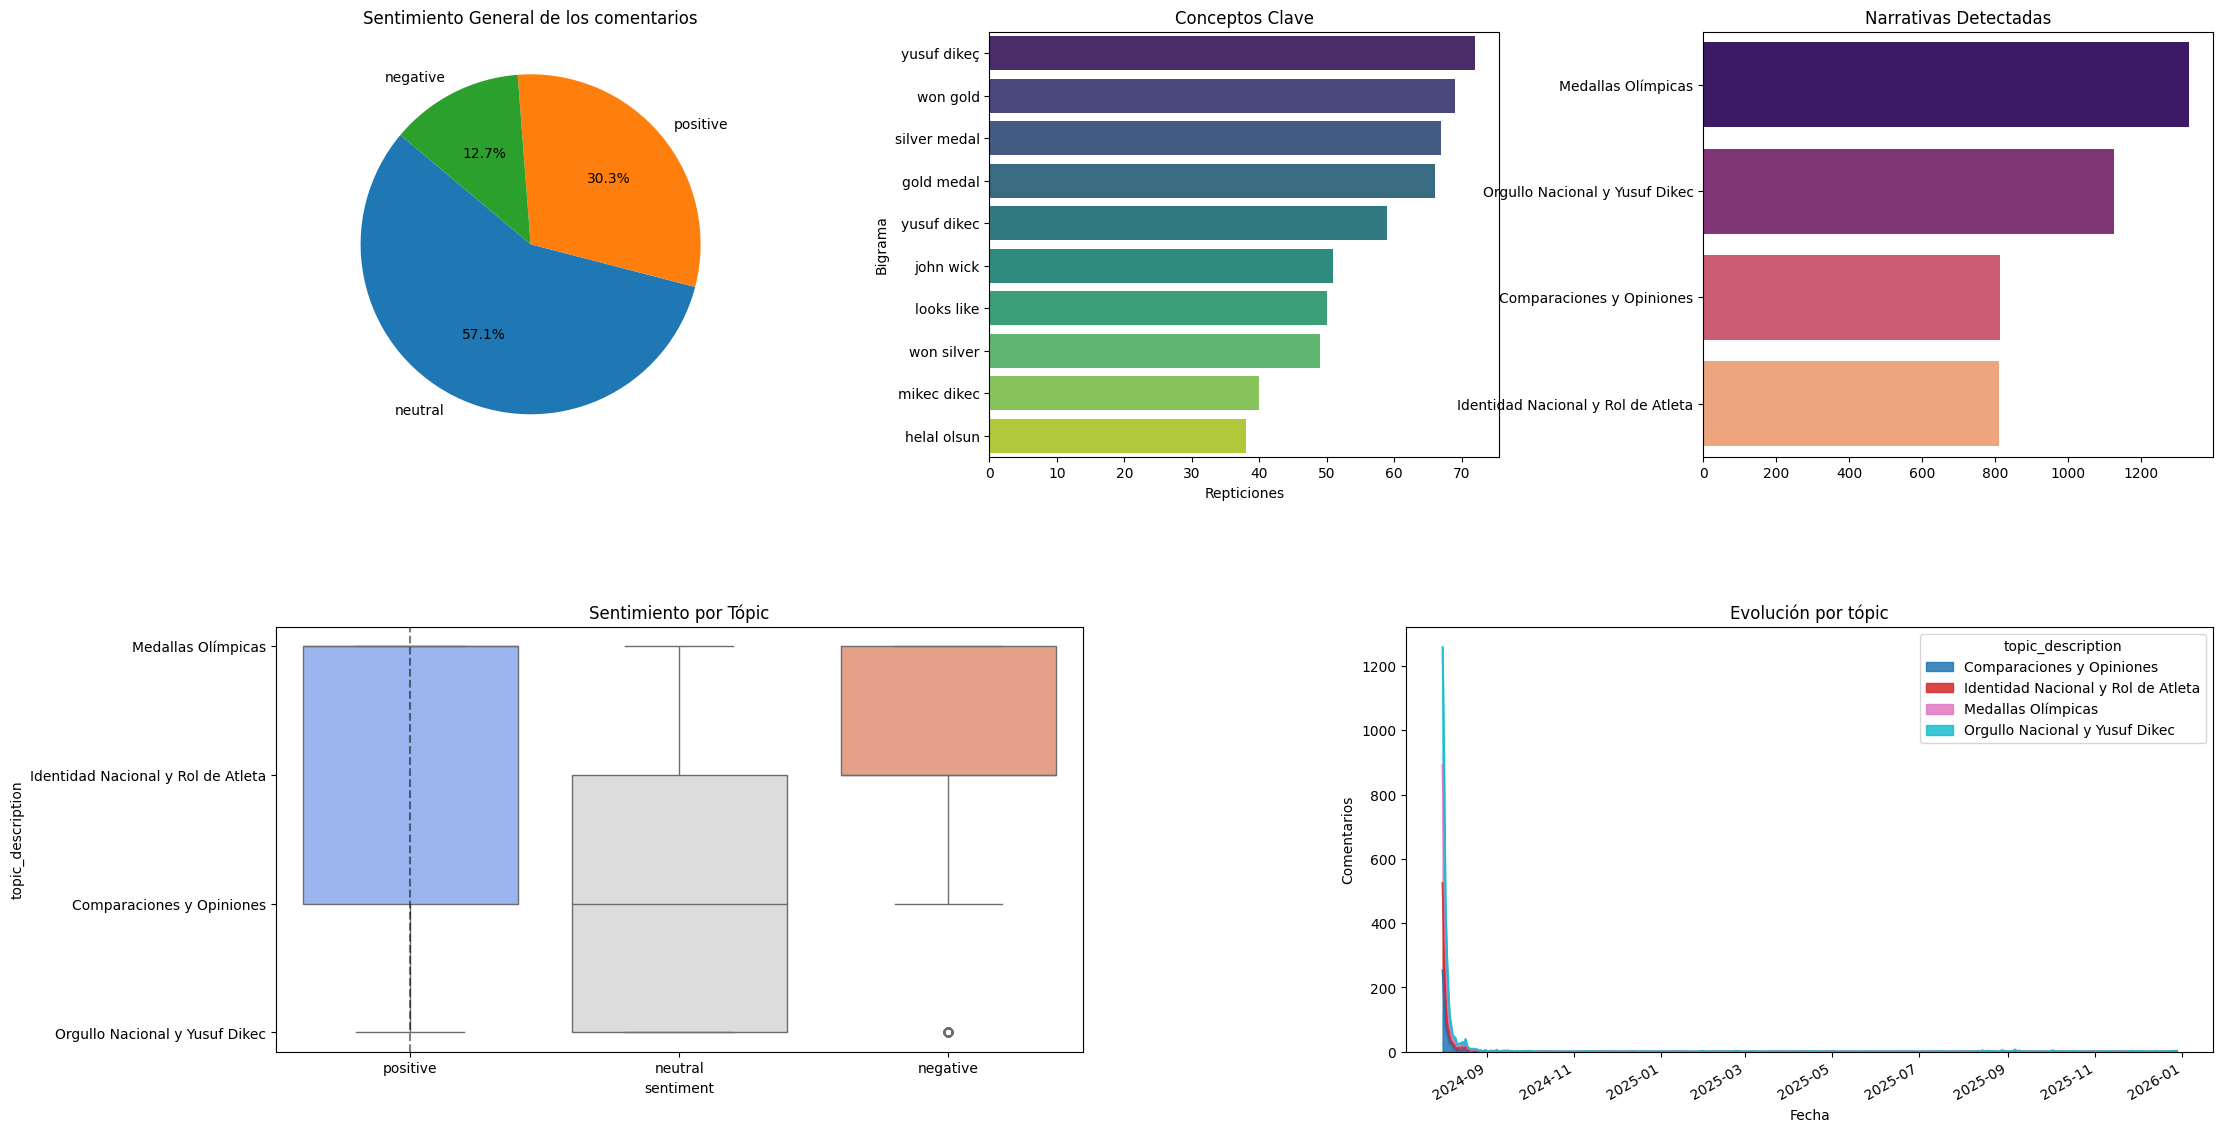

In [78]:
fig = plt.figure(figsize=(25,15))
plt.subplots_adjust(hspace=0.4, wspace=0.4)

# sentimientos
ax1 = plt.subplot(2, 3, 1)
sentiments_counts = df_processed['sentiment'].value_counts()
ax1.pie(sentiments_counts, labels=sentiments_counts.index, autopct='%1.1f%%', startangle=140)
ax1.set_title('Sentimiento General de los comentarios')
# bias
ax2 = plt.subplot(2, 3, 2)
sns.barplot(x='Frecuencia', y='Bigrama', data=df_bias, palette='viridis', ax=ax2)
ax2.set_title('Conceptos Clave')
ax2.set_xlabel('Repticiones')

# volumen pot tópico
ax3 = plt.subplot(2, 3, 3)
sns.countplot(y='topic_description', data=df_processed, order=df_processed['topic_description'].value_counts().index, palette='magma', ax=ax3)
ax3.set_title('Narrativas Detectadas')
ax3.set_xlabel('')
ax3.set_ylabel('')
# sentimiento por tópico
ax4 = plt.subplot(2, 2, 3)
sns.boxplot(x='sentiment', y='topic_description', data=df_processed, palette='coolwarm', ax=ax4)
ax4.set_title('Sentimiento por Tópic')
ax4.axvline(0, color='black', linestyle='--', alpha=0.5)

# evolución temporal
ax5 = plt.subplot(2, 2, 4)
df_time = df_processed.groupby([pd.Grouper(key='published_at', freq='D'), 'topic_description']).size().unstack(fill_value=0)
df_time.plot(kind='area', stacked=True, ax=ax5, alpha=0.85, colormap='tab10')
ax5.set_title('Evolución por tópic')
ax5.set_ylabel('Comentarios')
ax5.set_xlabel('Fecha')

## Conclusiones

Las técnicas de NLP empleadas son:

**Gráfica Sentimiento General de los comentarios**: Domina el sentimiento neutral con un 57.1% de los comentarios en base al modelo **SentimentIntensityAnalyzer** empleado, luego tenemos un 30% de comentarios positivos y 12,7% de comentarios negativos, el objetivo de este gráfico es poder ver de forma sencilla el tipo de comentarios que se han publicado sobre esta persona que se volvió tan viral en los Juegos Olímpicos.

**Gráfica Conceptos Clave**: Se observan los términos más repetidos en los comentarios del video y vemos como el público menciona al autor 'Yusuf Dikec', también se mencionan las medallas que se disputaba (el oro y la plata) y hay 2 comentarios interesantes que son 'looks like' y 'john wick' que es un actor estadounidense y se observa claramente que el estilo de tiro Yusuf puede parecerse al de este actor según dice la audiencia. También observamos que aquí es donde y como la audiencia crea el meme entre el estilo de tiro en los Juegos Olímpicos y el Cine de acción.

**Gráfica Narrativas Detectadas**: Se han agrupado los comentarios por los tópics que hemos definido para darle un significado a cada uno y podemos concluir que hay un fuerte debate o tema de conversación sobre las medallas olímpicas (en 1º lugar), pero también se habla mucho sobre la narrativa del meme Comparaciones y opiniones (3º lugar).

**Gráfica Sentimiento por Tópic**: Observamos una clara concentración positiva en los tópic (Medallas Olímpicas e Identidad Nacional y Rol del Atleta) lo que sugiere comentarios positivos en estos temas. El sentimiento neutral se reparte (Identidad Nacional y Rol del Atleta, Comparaciones y Opiniones, Orgullo Nacional y Yusuf Dikec), la mediana está centrada en Comparaciones y Opiniones pudiendo indicar comentarios descriptivos o informativos sobre este tópic transmitiendo mensajes neutros. Por último, el sentimiento negativo se centra en el tópic dedicado a las Medallas Olímpicas siendo el menos dominante, podemos decir que tratan debates acerca del resultado.

**Gráfica Evolución por tópic**: Para todos los tópic analizados observamos el mismo patrón, un pico en los primeros días de publicación del vídeo y luego peuqñeas conversaciones, pero se ve claramente el pico de tendencia sobre este hecho viral y como con el paso de los días se desvaneció.

